# Polinomial Models

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Sample dataset
data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,9,10],
    'Exam_Score': [50,65,75,80,85,88,89,88,85,80]
}

# Create a DataFrame from the dataset
df = pd.DataFrame(data)

In [3]:
# Extract the features (Study_Hours) and target (Exam_Score)
X = np.array(data['Study_Hours']).reshape(-1, 1)
y = np.array(data['Exam_Score']).reshape(-1,1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
# Fit linear regression for comparison
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
reg = LinearRegression().fit(X_train, y_train)
# Fit polynomial regression
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('linear', LinearRegression())])

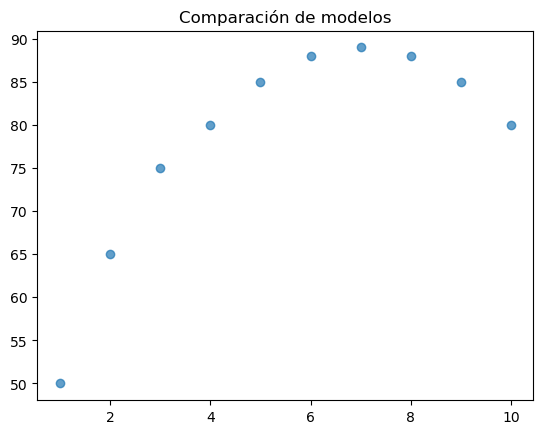

Modelo Lineal
MSE: 20.1667
R²: 0.7983

Modelo Polinomial
MSE: 2.1182
R²: 0.9788


In [7]:
# Plot results
import matplotlib.pyplot as plt
plt.scatter(X, y, alpha=0.7, label='Datos reales')
plt.title("Comparación de modelos")
plt.show()

# Evaluate the models
from sklearn.metrics import mean_squared_error, r2_score
y_pred1 = reg.predict(X_test)
y_pred2 = poly_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

mse_poly = mean_squared_error(y_test, y_pred2)
r2_poly = r2_score(y_test, y_pred2)

print("Modelo Lineal")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

print("\nModelo Polinomial")
print(f"MSE: {mse_poly:.4f}")
print(f"R²: {r2_poly:.4f}")

# Exponential regression

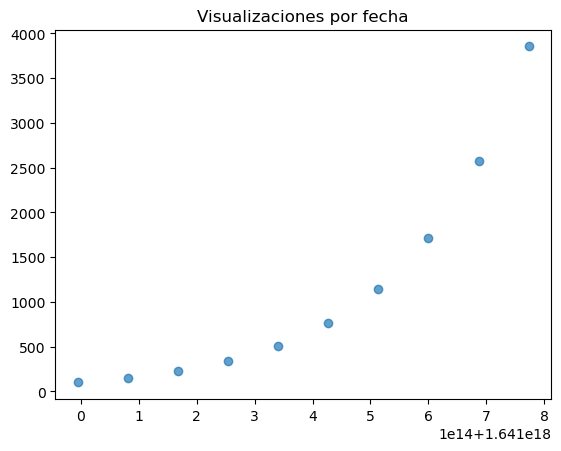

Modelo Lineal
MSE: 91462.9780
R²: 0.9375

Modelo Exponencial
MSE: 0.0468
R²: 1.0000


In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor
# Sample dataset
data = {
    'Date': pd.date_range(start='2022-01-01', periods=10),
    'Engaged_Users': [100,150,225,338,507,761,1142,1713,2570,3855]
}

# Create a DataFrame from the dataset
df = pd.DataFrame(data)

# Extract the features (Date) and target (Engaged_Users)
X_dt = pd.to_numeric(df['Date'])
X = np.array(X_dt).reshape(-1, 1)
y = np.array(df['Engaged_Users']).reshape(-1, 1)
# Visualize the data
plt.scatter(X, y, alpha=0.7, label='Datos reales')
plt.title("Visualizaciones por fecha")
plt.show()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Fit linear regression for comparison

reg = LinearRegression().fit(X_train, y_train)
# Fit exponential regression
y_train_exp = y_train.copy()
if np.any(y_train_exp <= 0):
    y_train_exp = y_train_exp - y_train_exp.min() + 1  # Evitar log(0)

# Crear modelo exponencial con transformación logarítmica
exp_reg = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp
)
exp_reg.fit(X_train, y_train_exp)

y_pred_exp = exp_reg.predict(X_test)

# Si ajustamos y_train, necesitamos ajustar y_test también para evaluación consistente
if np.any(y_train <= 0):
    y_test_adj = y_test - y_train.min() + 1
    mse_exp = mean_squared_error(y_test_adj, y_pred_exp)
    r2_exp = r2_score(y_test_adj, y_pred_exp)
else:
    mse_exp = mean_squared_error(y_test, y_pred_exp)
    r2_exp = r2_score(y_test, y_pred_exp)

# Evaluate the models
from sklearn.metrics import mean_squared_error, r2_score
y_pred1 = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

print("Modelo Lineal")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

print("\nModelo Exponencial")
print(f"MSE: {mse_exp:.4f}")
print(f"R²: {r2_exp:.4f}")

# Power models

In [34]:
# Import libraries

# Create a DataFrame with the sample data
data = {
    'User_ID': range(1, 11),
    'Followers': np.arange(10, 110, 10),
    'Likes': [25,50,100,200,350,550,800,1100,1450,1850],
    'Shares': [5,10,20,40,70,110,160,220,290,370],
    'Comments': [2,4,8,16,28,44,64,88,116,148]
}
df = pd.DataFrame(data)

# Perform power regression for Likes as an example



# Generate a range of Followers values for the fitted curve

# Calculate the predicted Likes using the fitted parameters

# Create a plot to visualize the relationship

